<a href="https://colab.research.google.com/github/atharvsalokhe30/Deep_Learning-_project_practice/blob/main/Image_Classification_on_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf                                      # this is deep laerning framework used to build and train CNN model.
from tensorflow.keras.datasets import fashion_mnist          # provides the fashion MNIST Dataset
from tensorflow.keras.models import Sequential               # used to create the CNN model layer by layer
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation

In [4]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Display the shape of the dataset
print("Training Image Shape :", X_train.shape)
print("Training Label Shape :", y_train.shape)
print("Testing Image Shape :", X_test.shape)
print("Testing Label Shape :", y_test.shape)

Training Image Shape : (60000, 28, 28)
Training Label Shape : (60000,)
Testing Image Shape : (10000, 28, 28)
Testing Label Shape : (10000,)


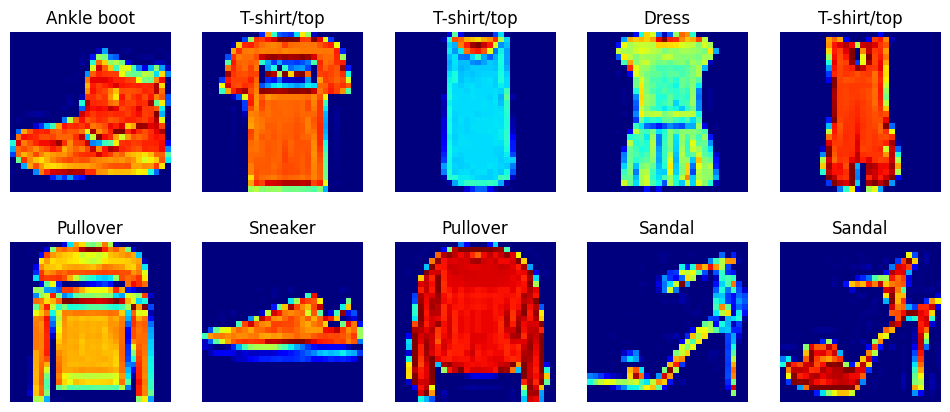

In [53]:
# Define class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] # 10 cloths category corresponding
# Display the first 10 training images
plt.figure(figsize=(12,5)) # creates a figure to display multiple images

for i in range(10):                     #loops through the first 10 training images
    plt.subplot(2,5,i+1)                #Arranges the images in 2 row and 5 column
    plt.imshow(X_train[i], cmap='jet') #cmap = gray display the image
    plt.title(class_names[y_train[i]])  # display the actual class name
    plt.axis('off')                     # hide the axis for cleaner display
plt.show()

In [29]:
# Display the pixel values of the first training image
X_train[6]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   3,
          1,   0,   4,   0,   0,   0,   2,   0,   0,   0,   0,   5,   1,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   4,
          0,   0,   0,   0,   0, 106, 229,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,
          0,   0,  90, 138, 223, 214, 209, 167,   0,   0,   0,   6, 124,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,  37,
        122, 179, 249, 214, 195, 181, 213, 241,   0,   0,   0,  94, 179,
          0,   0],
       [  0,   0,   0,   2,   0,   6,   0,   0,   0,   0,  16, 149, 236,
        226, 201, 195, 200, 204, 155, 209, 116,   0,  22, 109, 251,  35,
         51,   0],
       [  0,   0,   1,   3,   0,   0,   0,   0,  67, 150, 240, 221, 194,
        190, 204, 214, 205, 195, 207, 185, 206, 233, 224, 179,   2,  10,
         22,   0],
       [  0,   0,   0,   0,   0,   0, 110, 214, 237, 209, 196, 192, 215,
        215, 213, 213, 207, 193, 186, 199, 206, 175,   0,   0, 124, 230,
        200,  36],
       [  0,  50, 119, 158, 166, 192, 204, 198, 187, 202, 203, 211, 214,
        204, 209, 210, 204, 197, 191, 190, 191, 229, 230, 242, 214, 193,
        203, 137],
       [108, 190, 199, 200, 194, 199, 194, 195, 199, 200, 189, 187, 191,
        189, 197, 198, 205, 200, 200, 208, 213, 215, 212, 213, 209, 202,
        216, 137],
       [ 15,  55, 114, 157, 188, 207, 216, 220, 217, 219, 221, 242, 240,
        243, 249, 253, 255, 255, 243, 232, 226, 222, 221, 213, 215, 198,
        209,  62],
       [ 16,  11,   0,   0,   7,  40,  76, 108, 134, 142, 143, 145, 143,
        123, 111,  92,  76,  61,  45,  35,  25,  25,  31,  32,  32,  12,
          1,   0],
       [  0,  11,  25,  26,  26,  22,  12,  20,  15,  15,  18,  17,  19,
         27,  30,  36,  41,  49,  57,  66,  79,  84,  79,  83,  93,  80,
         75,  45],
       [  0,   0,   0,   0,   0,   9,  14,  17,  27,  34,  39,  39,  42,
         44,  41,  41,  43,  48,  43,  30,  31,  35,  40,  37,  40,  37,
         26,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [30]:
#display pixel values
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0
Maximum Pixel Value : 255


In [31]:
# normalize pixel scale
X_train = X_train / 255.0
X_test = X_test / 255.0

In [32]:
# reshape the training and testing images

X_train.reshape(60000, 28, 28, 1)
X_test.reshape(10000, 28, 28, 1)

# Display the new shape
print("training images shape:", X_train.shape)
print("testing images shape:", X_test.shape)

training images shape: (60000, 28, 28)
testing images shape: (10000, 28, 28)


In [33]:
# builld the cnn model
model = Sequential([
    # convolutional layer
    Conv2D(           # applies convolutional operation to the images
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),
    #Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # convert feature maps into a one-dimensional vector
    Flatten(),

    # Fully connected hidden layer
    Dense(128, activation='relu'),

    # output layer
    Dense(10, activation='softmax')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
# display the cnn model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# compile the cnn model
model.compile(
    optimizer='adam', # specifies the adam optimizer which updates
    loss='sparse_categorical_crossentropy',   # calculates the error
    metrics=['accuracy']   # ells TensorFlow to display the classification
)

In [37]:
history= model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.8537 - loss: 0.4140 - val_accuracy: 0.8858 - val_loss: 0.3208
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.8980 - loss: 0.2819 - val_accuracy: 0.8988 - val_loss: 0.2807
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9137 - loss: 0.2340 - val_accuracy: 0.9085 - val_loss: 0.2578
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9264 - loss: 0.2027 - val_accuracy: 0.9093 - val_loss: 0.2565
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9362 - loss: 0.1740 - val_accuracy: 0.9103 - val_loss: 0.2522
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9451 - loss: 0.1497 - val_accuracy: 0.9134 - val_loss: 0.2493
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9539 - loss: 0.1261 - val_accuracy: 0.9157 - val_loss: 0.2632
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9604 -

In [38]:
# Evaluate the cnn model on the testing dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9004 - loss: 0.3548
Test Loss: 0.3547934293746948
Test Accuracy: 0.9003999829292297


In [39]:
# predict the classes of the testing images
predictions = model.predict(X_test)

# Display the prediction probabilities of the first image
print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
[7.8487652e-08 7.5272830e-11 2.2571861e-07 8.9436153e-10 7.1701034e-10
 9.1319839e-07 7.2123774e-10 6.0461316e-06 1.4639271e-08 9.9999267e-01]


In [40]:
# convert probability values into predicted class labels

predicted_classes = np.argmax(predictions, axis=1)
print("predicted classes:",predicted_classes[0])
print("actual classes:", y_test[0])

predicted classes: 9
actual classes: 9


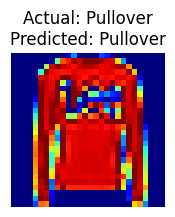

In [52]:
# Display the first testing image with actual and predicted

plt.figure(figsize=(2,2))
plt.imshow(X_test[1].reshape(28,28), cmap='jet')
plt.title(f"Actual: {class_names[y_test[1]]}\nPredicted: {class_names[predicted_classes[1]]}")
plt.axis('off')
plt.show()